<a href="https://colab.research.google.com/github/biku34/eeg-sleep-classification/blob/main/NetSip_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q mne awscli
import mne, numpy, scipy, sklearn
print('mne', mne.__version__, '| numpy', numpy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
mne 1.12.1 | numpy 2.0.2


In [5]:
import os, glob, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
SFREQ = 100

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DATA_ROOT     = '/content/drive/MyDrive/sleep-stage-eeg-data'
SC_DIR        = f'{DATA_ROOT}/raw/sleep-cassette'
PROCESSED_DIR = f'{DATA_ROOT}/processed'
os.makedirs(SC_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print('Data root:', DATA_ROOT)

Data root: /content/drive/MyDrive/sleep-stage-eeg-data


In [5]:
!aws s3 sync --no-sign-request \
  s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/ \
  "$SC_DIR"
print('\nPSG files present:', len(glob.glob(f'{SC_DIR}/*PSG.edf')), '/ 153')

download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4041EC-Hypnogram.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4041EC-Hypnogram.edf
download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4031EC-Hypnogram.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4031EC-Hypnogram.edf
download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4032EP-Hypnogram.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4032EP-Hypnogram.edf
download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4042EC-Hypnogram.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4042EC-Hypnogram.edf
download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4031E0-PSG.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4031E0-PSG.edf
download: s3://physionet-open/sleep-edfx/1.0.0/sleep-cassette/SC4061EC-Hypnogram.edf to drive/MyDrive/sleep-stage-eeg-data/raw/sleep-cassette/SC4061EC-Hypnogram.edf
download: s3://physion

In [6]:
psg = sorted(glob.glob(f'{SC_DIR}/*PSG.edf'))[0]
raw = mne.io.read_raw_edf(psg, preload=False, verbose='ERROR')
print('File     :', os.path.basename(psg))
print('Channels :', raw.ch_names)
print('Sfreq    :', raw.info['sfreq'], 'Hz')
print('Duration :', round(raw.times[-1] / 3600, 2), 'hours')

File     : SC4001E0-PSG.edf
Channels : ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sfreq    : 100.0 Hz
Duration : 22.08 hours


In [7]:
ANN_TO_CODE = {
    'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
    'Sleep stage 3': 3, 'Sleep stage 4': 3,      # merge R&K 3 & 4 -> N3
    'Sleep stage R': 4,
}
STAGE_EVENT_ID = {'Wake': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4}
SLEEP_DESCS = {'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3',
               'Sleep stage 4', 'Sleep stage R'}

def process_recording(psg_path, hypno_path):
    """One recording -> (X, y). X = (n_epochs, 3000), y = 0..4."""
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose='ERROR')
    raw.pick(['EEG Fpz-Cz'])                       # single channel

    ann = mne.read_annotations(hypno_path)
    raw.set_annotations(ann, emit_warning=False)   # labels BEFORE crop/filter

    onset, dur, desc = (raw.annotations.onset, raw.annotations.duration,
                        raw.annotations.description)
    sleep_idx = [i for i, d in enumerate(desc) if d in SLEEP_DESCS]
    if not sleep_idx:
        return None
    first = onset[sleep_idx[0]]
    last  = onset[sleep_idx[-1]] + dur[sleep_idx[-1]]
    raw.crop(tmin=max(0.0, first - 30 * 60),
             tmax=min(raw.times[-1], last + 30 * 60))   # 30 min either side

    raw.filter(0.3, 35.0, verbose='ERROR')         # band-pass

    events, _ = mne.events_from_annotations(
        raw, event_id=ANN_TO_CODE, chunk_duration=30.0, verbose='ERROR')
    epochs = mne.Epochs(raw, events, event_id=STAGE_EVENT_ID,
        tmin=0.0, tmax=30.0 - 1.0 / SFREQ,          # -> exactly 3000 samples
        baseline=None, preload=True, verbose='ERROR')

    X = epochs.get_data().squeeze(1)               # (n, 1, 3000) -> (n, 3000)
    y = epochs.events[:, 2]
    return X, y

In [10]:
from tqdm import tqdm

def list_recording_pairs(sc_dir):
    hypnos = glob.glob(f'{sc_dir}/*Hypnogram.edf')
    pairs = []
    for psg in sorted(glob.glob(f'{sc_dir}/*PSG.edf')):
        prefix = os.path.basename(psg)[:6]          # e.g. SC4001
        match = [h for h in hypnos if os.path.basename(h).startswith(prefix)]
        if not match:
            print('  no hypnogram for', os.path.basename(psg), '- skipping'); continue
        pairs.append((psg, match[0], prefix[3:5], prefix))   # psg, hyp, subject, prefix
    return pairs

pairs = list_recording_pairs(SC_DIR)
print(f'Found {len(pairs)} usable recording pairs\n')

all_y = []
for psg, hyp, subj, prefix in tqdm(pairs):
    out = f'{PROCESSED_DIR}/{prefix}.npz'
    if os.path.exists(out):                         # already done -> skip
        all_y.append(np.load(out)['y']); continue
    try:
        res = process_recording(psg, hyp)
        if res is None: continue
        X, y = res
        np.savez_compressed(out, X=X.astype(np.float32),
                            y=y.astype(np.int64), subject=subj)
        all_y.append(y)
    except Exception as e:
        print(f'  FAILED {prefix}: {e}')

all_y = np.concatenate(all_y)
print(f'\nTotal epochs: {len(all_y):,} across {len(pairs)} recordings')
for v, c in zip(*np.unique(all_y, return_counts=True)):
    print(f'  {STAGE_NAMES[v]:4s}: {c:6d} ({100*c/len(all_y):.1f}%)')

Found 153 usable recording pairs



100%|██████████| 153/153 [04:26<00:00,  1.74s/it]


Total epochs: 195,469 across 153 recordings
  Wake:  65941 (33.7%)
  N1  :  21522 (11.0%)
  N2  :  69132 (35.4%)
  N3  :  13039 (6.7%)
  REM :  25835 (13.2%)


In [9]:
def process_recording(psg_path, hypno_path):
    """One recording -> (X, y). X = (n_epochs, 3000), y = 0..4."""
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose='ERROR')
    raw.pick(['EEG Fpz-Cz'])

    ann = mne.read_annotations(hypno_path)
    raw.set_annotations(ann, emit_warning=False)

    onset, dur, desc = (raw.annotations.onset, raw.annotations.duration,
                        raw.annotations.description)
    sleep_idx = [i for i, d in enumerate(desc) if d in SLEEP_DESCS]
    if not sleep_idx:
        return None
    first = onset[sleep_idx[0]]
    last  = onset[sleep_idx[-1]] + dur[sleep_idx[-1]]
    raw.crop(tmin=max(0.0, first - 30 * 60),
             tmax=min(raw.times[-1], last + 30 * 60))

    raw.filter(0.3, 35.0, verbose='ERROR')

    events, _ = mne.events_from_annotations(
        raw, event_id=ANN_TO_CODE, chunk_duration=30.0, verbose='ERROR')

    # --- FIX: only request stages that actually appear in THIS recording ---
    present = set(events[:, 2])
    event_id = {name: code for name, code in STAGE_EVENT_ID.items() if code in present}
    # ----------------------------------------------------------------------

    epochs = mne.Epochs(raw, events, event_id=event_id,
        tmin=0.0, tmax=30.0 - 1.0 / SFREQ,          # -> exactly 3000 samples
        baseline=None, preload=True, verbose='ERROR')

    X = epochs.get_data().squeeze(1)
    y = epochs.events[:, 2]
    return X, y

In [11]:
from scipy import signal
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid           # numpy-2 safe (np.trapz was removed)

BANDS = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12),
         'sigma': (12, 16), 'beta': (16, 30)}
FEATURE_NAMES = list(BANDS) + ['std', 'skew', 'kurt', 'zcr']

def epoch_features(epoch, sfreq=SFREQ):
    freqs, psd = signal.welch(epoch, fs=sfreq, nperseg=min(len(epoch), 256))
    total = trapezoid(psd, freqs) + 1e-12
    feats = [trapezoid(psd[(freqs >= lo) & (freqs < hi)],
                       freqs[(freqs >= lo) & (freqs < hi)]) / total
             for lo, hi in BANDS.values()]         # relative band power
    feats += [np.std(epoch), skew(epoch), kurtosis(epoch),
              ((epoch[:-1] * epoch[1:]) < 0).mean()]
    return np.array(feats, dtype=np.float32)

def build_feature_table(processed_dir):
    X_list, y_list, g_list = [], [], []
    for f in tqdm(sorted(glob.glob(f'{processed_dir}/*.npz'))):
        d = np.load(f)
        X, y, subj = d['X'], d['y'], str(d['subject'])
        X_list.append(np.stack([epoch_features(e) for e in X]))
        y_list.append(y)
        g_list.append(np.full(len(y), subj))
    return (np.concatenate(X_list), np.concatenate(y_list), np.concatenate(g_list))

X_feat, y, groups = build_feature_table(PROCESSED_DIR)
print('Feature table :', X_feat.shape)
print('Subjects      :', len(set(groups)))

100%|██████████| 153/153 [14:43<00:00,  5.77s/it]

Feature table : (195469, 9)
Subjects      : 78


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, f1_score,
                             cohen_kappa_score, confusion_matrix)

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

accs, macro_f1s, kappas = [], [], []
y_true_all, y_pred_all, importances = [], [], []

for i, (tr, te) in enumerate(gkf.split(X_feat, y, groups), 1):
    clf = RandomForestClassifier(
        n_estimators=100,          # was 200 -> half the work
        min_samples_leaf=5,        # stops trees growing to full depth -> much faster
        class_weight='balanced', random_state=SEED, n_jobs=-1)
    clf.fit(X_feat[tr], y[tr])
    pred = clf.predict(X_feat[te])
    a = accuracy_score(y[te], pred)
    k = cohen_kappa_score(y[te], pred)
    accs.append(a); kappas.append(k)
    macro_f1s.append(f1_score(y[te], pred, average='macro', zero_division=0))
    y_true_all.append(y[te]); y_pred_all.append(pred)
    importances.append(clf.feature_importances_)
    print(f'  fold {i}/{N_SPLITS} done  |  acc={a:.3f}  kappa={k:.3f}')   # live feedback

print('\n=== Subject-wise 5-fold baseline (Random Forest) ===')
print(f'Accuracy     : {np.mean(accs):.3f} +/- {np.std(accs):.3f}')
print(f'Macro-F1     : {np.mean(macro_f1s):.3f} +/- {np.std(macro_f1s):.3f}')
print(f"Cohen's kappa: {np.mean(kappas):.3f} +/- {np.std(kappas):.3f}")

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)
print('\nPer-class F1:')
for n, f in zip(STAGE_NAMES, f1_score(y_true_all, y_pred_all,
                                      average=None, labels=[0,1,2,3,4], zero_division=0)):
    print(f'  {n:4s}: {f:.3f}')

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1,2,3,4])
cmn = cm / cm.sum(axis=1, keepdims=True)
print('\nConfusion (rows=true, cols=pred):')
print('        ' + '  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for i, n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  ' + '  '.join(f'{cmn[i,j]:5.2f}' for j in range(5)))

print('\nFeature importance:')
for n, v in sorted(zip(FEATURE_NAMES, np.mean(importances, axis=0)), key=lambda x: -x[1]):
    print(f'  {n:6s}: {v:.3f}')

  fold 1/5 done  |  acc=0.731  kappa=0.627
  fold 2/5 done  |  acc=0.707  kappa=0.599
  fold 3/5 done  |  acc=0.725  kappa=0.625
  fold 4/5 done  |  acc=0.732  kappa=0.634
  fold 5/5 done  |  acc=0.737  kappa=0.648

=== Subject-wise 5-fold baseline (Random Forest) ===
Accuracy     : 0.726 +/- 0.011
Macro-F1     : 0.655 +/- 0.015
Cohen's kappa: 0.627 +/- 0.016

Per-class F1:
  Wake: 0.848
  N1  : 0.296
  N2  : 0.802
  N3  : 0.769
  REM : 0.564

Confusion (rows=true, cols=pred):
         Wake     N1     N2     N3    REM
  Wake   0.84   0.08   0.02   0.01   0.05
  N1     0.20   0.28   0.24   0.00   0.27
  N2     0.03   0.06   0.77   0.04   0.09
  N3     0.05   0.00   0.13   0.81   0.00
  REM    0.09   0.16   0.11   0.01   0.63

Feature importance:
  beta  : 0.205
  std   : 0.187
  zcr   : 0.141
  sigma : 0.112
  alpha : 0.087
  delta : 0.082
  theta : 0.079
  kurt  : 0.066
  skew  : 0.040


In [9]:
import glob, shutil, os, time

# 1. Copy processed .npz from Drive -> fast local disk (Drive mount is flaky for bulk reads)
LOCAL_PROC = '/content/processed_local'
os.makedirs(LOCAL_PROC, exist_ok=True)
for f in sorted(glob.glob(f'{PROCESSED_DIR}/*.npz')):
    dst = os.path.join(LOCAL_PROC, os.path.basename(f))
    if os.path.exists(dst):
        continue
    for attempt in range(5):                     # retry if Drive drops the connection
        try:
            shutil.copy(f, dst); break
        except Exception as e:
            print('retry', os.path.basename(f), attempt, '-', e); time.sleep(2)
print('Local .npz files:', len(glob.glob(f'{LOCAL_PROC}/*.npz')))

# 2. Load from local disk (fast, reliable)
Xr, yr, gr = [], [], []
for f in sorted(glob.glob(f'{LOCAL_PROC}/*.npz')):
    d = np.load(f)
    Xr.append(d['X']); yr.append(d['y'])
    gr.append(np.full(len(d['y']), str(d['subject'])))
Xr = np.concatenate(Xr).astype(np.float32)
yr = np.concatenate(yr).astype(np.int64)
gr = np.concatenate(gr)
# per-epoch z-score: each window normalized by its OWN stats -> no train/test leakage
Xr = (Xr - Xr.mean(axis=1, keepdims=True)) / (Xr.std(axis=1, keepdims=True) + 1e-7)
Xr = Xr[:, None, :]                              # (n, 1, 3000) for Conv1d
print('CNN data:', Xr.shape, '| subjects:', len(set(gr)), '| RAM:', round(Xr.nbytes/1e9, 2), 'GB')

Local .npz files: 153
CNN data: (195469, 1, 3000) | subjects: 78 | RAM: 2.35 GB


In [8]:
import glob
Xr, yr, gr = [], [], []
for f in sorted(glob.glob(f'{PROCESSED_DIR}/*.npz')):
    d = np.load(f)
    Xr.append(d['X']); yr.append(d['y'])
    gr.append(np.full(len(d['y']), str(d['subject'])))
Xr = np.concatenate(Xr).astype(np.float32)
yr = np.concatenate(yr).astype(np.int64)
gr = np.concatenate(gr)
# per-epoch z-score: each 30-s window normalized by its OWN stats -> no train/test leakage
Xr = (Xr - Xr.mean(axis=1, keepdims=True)) / (Xr.std(axis=1, keepdims=True) + 1e-7)
Xr = Xr[:, None, :]                          # (n, 1, 3000) channel dim for Conv1d
print('CNN data:', Xr.shape, '| subjects:', len(set(gr)), '| RAM:', round(Xr.nbytes/1e9,2), 'GB')

ConnectionAbortedError: [Errno 103] Software caused connection abort

In [10]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)                      # should say cuda

class SleepCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=50, stride=6, padding=25),  # WIDE first kernel (~0.5 s)
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(8),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=8, padding=4),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),          # -> 128-d per-epoch embedding (reused for the LSTM later)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.features(x))

Device: cuda


In [11]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def make_loader(idx, bs=128, shuffle=False):
    ds = TensorDataset(torch.from_numpy(Xr[idx]), torch.from_numpy(yr[idx]))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=2, pin_memory=True)

def class_weights(y_tr, n=5):
    counts = np.bincount(y_tr, minlength=n).astype(np.float32)
    return torch.tensor(len(y_tr) / (n * np.maximum(counts, 1)),
                        dtype=torch.float32, device=device)

def evaluate(model, loader):
    model.eval(); P, T = [], []
    with torch.no_grad():
        for xb, yb in loader:
            P.append(model(xb.to(device)).argmax(1).cpu().numpy()); T.append(yb.numpy())
    P, T = np.concatenate(P), np.concatenate(T)
    return accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0), cohen_kappa_score(T,P)

tr, te = next(GroupKFold(n_splits=5).split(Xr, yr, gr))   # first fold only
train_loader, test_loader = make_loader(tr, shuffle=True), make_loader(te)

torch.manual_seed(SEED)
model = SleepCNN().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss(weight=class_weights(yr[tr]))

for ep in range(1, 13):
    model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        tot += loss.item() * len(yb)
    acc, mf1, kap = evaluate(model, test_loader)
    print(f'epoch {ep:2d} | loss {tot/len(tr):.3f} | test acc {acc:.3f}  macroF1 {mf1:.3f}  kappa {kap:.3f}')

epoch  1 | loss 0.745 | test acc 0.725  macroF1 0.639  kappa 0.630
epoch  2 | loss 0.671 | test acc 0.751  macroF1 0.688  kappa 0.665
epoch  3 | loss 0.652 | test acc 0.752  macroF1 0.696  kappa 0.667
epoch  4 | loss 0.635 | test acc 0.749  macroF1 0.696  kappa 0.664
epoch  5 | loss 0.624 | test acc 0.765  macroF1 0.700  kappa 0.682
epoch  6 | loss 0.613 | test acc 0.756  macroF1 0.705  kappa 0.674
epoch  7 | loss 0.604 | test acc 0.720  macroF1 0.664  kappa 0.631
epoch  8 | loss 0.598 | test acc 0.725  macroF1 0.676  kappa 0.638
epoch  9 | loss 0.593 | test acc 0.717  macroF1 0.640  kappa 0.625
epoch 10 | loss 0.586 | test acc 0.737  macroF1 0.677  kappa 0.648
epoch 11 | loss 0.580 | test acc 0.751  macroF1 0.688  kappa 0.664
epoch 12 | loss 0.575 | test acc 0.740  macroF1 0.675  kappa 0.652


In [12]:
import copy
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

def train_fold(tr_idx, val_idx, max_epochs=25, patience=5, lr=1e-3):
    train_loader, val_loader = make_loader(tr_idx, shuffle=True), make_loader(val_idx)
    torch.manual_seed(SEED)
    model = SleepCNN().to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights(yr[tr_idx]))
    best_f1, best_state, wait = -1, None, 0
    for ep in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        _, vf1, _ = evaluate(model, val_loader)          # watch VALIDATION, never test
        if vf1 > best_f1:
            best_f1, best_state, wait = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: break                   # early stop
    model.load_state_dict(best_state)                    # keep the BEST checkpoint
    return model

gkf = GroupKFold(n_splits=5)
accs, mf1s, kappas, yt_all, yp_all = [], [], [], [], []

for i, (trainval, test) in enumerate(gkf.split(Xr, yr, gr), 1):
    # carve ~20% of TRAINING SUBJECTS as validation (subject-disjoint, no leakage)
    inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_rel, val_rel = next(inner.split(Xr[trainval], yr[trainval], gr[trainval]))
    tr_idx, val_idx = trainval[tr_rel], trainval[val_rel]

    model = train_fold(tr_idx, val_idx)

    test_loader = make_loader(test)
    model.eval(); P, T = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            P.append(model(xb.to(device)).argmax(1).cpu().numpy()); T.append(yb.numpy())
    P, T = np.concatenate(P), np.concatenate(T)
    a, m, k = (accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0),
               cohen_kappa_score(T,P))
    accs.append(a); mf1s.append(m); kappas.append(k)
    yt_all.append(T); yp_all.append(P)
    print(f'fold {i}/5 | test acc {a:.3f}  macroF1 {m:.3f}  kappa {k:.3f}')

print('\n=== 1-D CNN · subject-wise 5-fold ===')
print(f'Accuracy     : {np.mean(accs):.3f} +/- {np.std(accs):.3f}')
print(f'Macro-F1     : {np.mean(mf1s):.3f} +/- {np.std(mf1s):.3f}')
print(f"Cohen's kappa: {np.mean(kappas):.3f} +/- {np.std(kappas):.3f}")

yt_all, yp_all = np.concatenate(yt_all), np.concatenate(yp_all)
print('\nPer-class F1:')
for n, f in zip(STAGE_NAMES, f1_score(yt_all, yp_all, average=None, labels=[0,1,2,3,4], zero_division=0)):
    print(f'  {n:4s}: {f:.3f}')
cm = confusion_matrix(yt_all, yp_all, labels=[0,1,2,3,4]); cmn = cm/cm.sum(1, keepdims=True)
print('\nConfusion (rows=true, cols=pred):')
print('        ' + '  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for r, n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  ' + '  '.join(f'{cmn[r,j]:5.2f}' for j in range(5)))

fold 1/5 | test acc 0.739  macroF1 0.676  kappa 0.652
fold 2/5 | test acc 0.720  macroF1 0.660  kappa 0.631
fold 3/5 | test acc 0.755  macroF1 0.707  kappa 0.674
fold 4/5 | test acc 0.767  macroF1 0.713  kappa 0.685
fold 5/5 | test acc 0.733  macroF1 0.703  kappa 0.652

=== 1-D CNN · subject-wise 5-fold ===
Accuracy     : 0.743 +/- 0.017
Macro-F1     : 0.692 +/- 0.020
Cohen's kappa: 0.659 +/- 0.019

Per-class F1:
  Wake: 0.892
  N1  : 0.422
  N2  : 0.778
  N3  : 0.701
  REM : 0.672

Confusion (rows=true, cols=pred):
         Wake     N1     N2     N3    REM
  Wake   0.84   0.12   0.00   0.00   0.04
  N1     0.09   0.54   0.18   0.01   0.18
  N2     0.00   0.13   0.70   0.10   0.06
  N3     0.00   0.01   0.14   0.85   0.00
  REM    0.02   0.20   0.05   0.01   0.72


In [13]:
import glob
Xr, yr, gr, rr = [], [], [], []
for ri, f in enumerate(sorted(glob.glob(f'{LOCAL_PROC}/*.npz'))):
    d = np.load(f)
    Xr.append(d['X']); yr.append(d['y'])
    gr.append(np.full(len(d['y']), str(d['subject'])))
    rr.append(np.full(len(d['y']), ri))          # recording id: which night this epoch is from
Xr = np.concatenate(Xr).astype(np.float32)
yr = np.concatenate(yr).astype(np.int64)
gr = np.concatenate(gr); rr = np.concatenate(rr)
Xr = (Xr - Xr.mean(1, keepdims=True)) / (Xr.std(1, keepdims=True) + 1e-7)
Xr = Xr[:, None, :]

SEQ_LEN = 20
seqs = []
for ri in np.unique(rr):
    idx = np.where(rr == ri)[0]                   # one night, in time order
    for s in range(0, len(idx), SEQ_LEN):
        chunk = idx[s:s + SEQ_LEN]
        if len(chunk) < SEQ_LEN:
            chunk = idx[-SEQ_LEN:]                # back-fill the last short window
        seqs.append(chunk)
seqs = np.stack(seqs)                             # (n_sequences, 20) of global epoch indices
seq_subject = np.array([gr[s[0]] for s in seqs]) # subject per sequence (for grouping)
print('sequences:', seqs.shape, '| subjects:', len(set(seq_subject)))

sequences: (9856, 20) | subjects: 78


In [14]:
class SeqDS(torch.utils.data.Dataset):
    def __init__(self, rows): self.rows = rows
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        gi = self.rows[i]
        return torch.from_numpy(Xr[gi]), torch.from_numpy(yr[gi]), torch.from_numpy(gi)

def seq_loader(rows, bs=32, shuffle=False):
    return DataLoader(SeqDS(rows), batch_size=bs, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

class SleepCNN_LSTM(nn.Module):
    def __init__(self, n_classes=5, hidden=128):
        super().__init__()
        self.cnn  = SleepCNN().features                       # 128-d embedding per epoch
        self.lstm = nn.LSTM(128, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(2 * hidden, n_classes))
    def forward(self, x):                                     # x: (B, L, 1, 3000)
        B, L = x.shape[:2]
        f = self.cnn(x.reshape(B * L, 1, x.shape[-1])).flatten(1)   # (B*L, 128)
        out, _ = self.lstm(f.reshape(B, L, 128))              # (B, L, 2*hidden)
        return self.head(out)                                 # (B, L, n_classes)

def evaluate_seq(model, loader):
    model.eval(); pred_by_idx = {}
    with torch.no_grad():
        for xb, yb, ib in loader:
            out = model(xb.to(device)).argmax(-1).cpu().numpy()     # (B, L)
            ib = ib.numpy()
            for b in range(ib.shape[0]):
                for t in range(ib.shape[1]):
                    pred_by_idx[int(ib[b, t])] = int(out[b, t])     # dedup overlaps
    idxs = np.array(sorted(pred_by_idx))
    return yr[idxs], np.array([pred_by_idx[i] for i in idxs])

In [15]:
import copy
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def train_seq_fold(tr_rows, val_rows, max_epochs=20, patience=4, lr=1e-3):
    tl, vl = seq_loader(tr_rows, shuffle=True), seq_loader(val_rows)
    crit = nn.CrossEntropyLoss(weight=class_weights(yr[np.concatenate(tr_rows)]))
    torch.manual_seed(SEED)
    model = SleepCNN_LSTM().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best, best_state, wait = -1, None, 0
    for ep in range(1, max_epochs + 1):
        model.train()
        for xb, yb, _ in tl:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb).reshape(-1, 5), yb.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
        T, P = evaluate_seq(model, vl)
        vf1 = f1_score(T, P, average='macro', zero_division=0)
        print(f'  epoch {ep:2d} | val macroF1 {vf1:.3f}')
        if vf1 > best: best, best_state, wait = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state); return model

gkf = GroupKFold(n_splits=5)
trainval, test = next(gkf.split(seqs, groups=seq_subject))
inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_rel, val_rel = next(inner.split(seqs[trainval], groups=seq_subject[trainval]))
tr_rows, val_rows, test_rows = seqs[trainval][tr_rel], seqs[trainval][val_rel], seqs[test]

model = train_seq_fold(tr_rows, val_rows)
T, P = evaluate_seq(model, seq_loader(test_rows))
print(f'\nCNN+BiLSTM (fold 1) | acc {accuracy_score(T,P):.3f}'
      f'  macroF1 {f1_score(T,P,average="macro",zero_division=0):.3f}'
      f'  kappa {cohen_kappa_score(T,P):.3f}')

  epoch  1 | val macroF1 0.466
  epoch  2 | val macroF1 0.720
  epoch  3 | val macroF1 0.651
  epoch  4 | val macroF1 0.707
  epoch  5 | val macroF1 0.658
  epoch  6 | val macroF1 0.707

CNN+BiLSTM (fold 1) | acc 0.824  macroF1 0.757  kappa 0.754


In [16]:
from sklearn.metrics import confusion_matrix

gkf = GroupKFold(n_splits=5)
accs, mf1s, kappas, yt_all, yp_all = [], [], [], [], []

for i, (trainval, test) in enumerate(gkf.split(seqs, groups=seq_subject), 1):
    inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_rel, val_rel = next(inner.split(seqs[trainval], groups=seq_subject[trainval]))
    tr_rows, val_rows, test_rows = seqs[trainval][tr_rel], seqs[trainval][val_rel], seqs[test]

    model = train_seq_fold(tr_rows, val_rows)
    T, P = evaluate_seq(model, seq_loader(test_rows))
    a, m, k = (accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0),
               cohen_kappa_score(T,P))
    accs.append(a); mf1s.append(m); kappas.append(k)
    yt_all.append(T); yp_all.append(P)
    print(f'fold {i}/5 | acc {a:.3f}  macroF1 {m:.3f}  kappa {k:.3f}')

print('\n=== CNN + BiLSTM · subject-wise 5-fold ===')
print(f'Accuracy     : {np.mean(accs):.3f} +/- {np.std(accs):.3f}')
print(f'Macro-F1     : {np.mean(mf1s):.3f} +/- {np.std(mf1s):.3f}')
print(f"Cohen's kappa: {np.mean(kappas):.3f} +/- {np.std(kappas):.3f}")

yt_all, yp_all = np.concatenate(yt_all), np.concatenate(yp_all)
print('\nPer-class F1:')
for n, f in zip(STAGE_NAMES, f1_score(yt_all, yp_all, average=None, labels=[0,1,2,3,4], zero_division=0)):
    print(f'  {n:4s}: {f:.3f}')
cm = confusion_matrix(yt_all, yp_all, labels=[0,1,2,3,4]); cmn = cm/cm.sum(1, keepdims=True)
print('\nConfusion (rows=true, cols=pred):')
print('        ' + '  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for r, n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  ' + '  '.join(f'{cmn[r,j]:5.2f}' for j in range(5)))

  epoch  1 | val macroF1 0.469
  epoch  2 | val macroF1 0.712
  epoch  3 | val macroF1 0.652
  epoch  4 | val macroF1 0.715
  epoch  5 | val macroF1 0.660
  epoch  6 | val macroF1 0.688
  epoch  7 | val macroF1 0.692
  epoch  8 | val macroF1 0.700
fold 1/5 | acc 0.820  macroF1 0.776  kappa 0.755
  epoch  1 | val macroF1 0.616
  epoch  2 | val macroF1 0.753
  epoch  3 | val macroF1 0.739
  epoch  4 | val macroF1 0.612
  epoch  5 | val macroF1 0.577
  epoch  6 | val macroF1 0.564
fold 2/5 | acc 0.751  macroF1 0.691  kappa 0.667
  epoch  1 | val macroF1 0.570
  epoch  2 | val macroF1 0.684
  epoch  3 | val macroF1 0.682
  epoch  4 | val macroF1 0.683
  epoch  5 | val macroF1 0.587
  epoch  6 | val macroF1 0.553
fold 3/5 | acc 0.770  macroF1 0.701  kappa 0.688
  epoch  1 | val macroF1 0.603
  epoch  2 | val macroF1 0.718
  epoch  3 | val macroF1 0.551
  epoch  4 | val macroF1 0.695
  epoch  5 | val macroF1 0.542
  epoch  6 | val macroF1 0.415
fold 4/5 | acc 0.766  macroF1 0.737  kappa 0.68

In [17]:
import torch
rng = np.random.RandomState(SEED)
all_subj = np.array(sorted(set(seq_subject)))
demo_subj = set(all_subj[rng.permutation(len(all_subj))[:6]])   # 6 subjects the model never sees
is_test = np.array([s in demo_subj for s in seq_subject])

tv_rows, tv_subj = seqs[~is_test], seq_subject[~is_test]
inner = GroupShuffleSplit(1, test_size=0.15, random_state=SEED)
tr_rel, val_rel = next(inner.split(tv_rows, groups=tv_subj))
final_model = train_seq_fold(tv_rows[tr_rel], tv_rows[val_rel])

MODEL_PATH = f'{DATA_ROOT}/cnn_bilstm_final.pt'
torch.save(final_model.state_dict(), MODEL_PATH)
print('Saved ->', MODEL_PATH)
print('Held-out demo subjects:', sorted(demo_subj))

  epoch  1 | val macroF1 0.701
  epoch  2 | val macroF1 0.721
  epoch  3 | val macroF1 0.654
  epoch  4 | val macroF1 0.666
  epoch  5 | val macroF1 0.691
  epoch  6 | val macroF1 0.654
Saved -> /content/drive/MyDrive/sleep-stage-eeg-data/cnn_bilstm_final.pt
Held-out demo subjects: [np.str_('00'), np.str_('10'), np.str_('12'), np.str_('33'), np.str_('34'), np.str_('82')]


Causal (online) accuracy on this night: 0.854


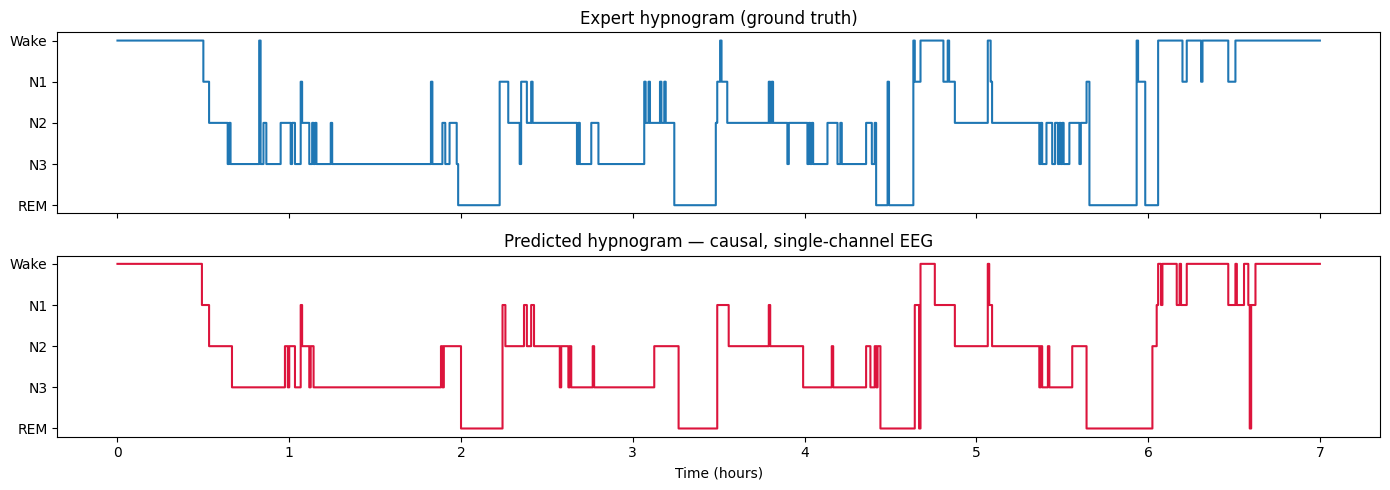

Saved -> demo_hypnogram.png


In [18]:
import matplotlib.pyplot as plt

# one held-out night the model never trained on
demo_ri = next(ri for ri in np.unique(rr) if gr[np.where(rr == ri)[0][0]] in demo_subj)
idx = np.where(rr == demo_ri)[0]                 # epochs in time order
Xn, yn = Xr[idx], yr[idx]

# CAUSAL streaming: predict epoch t using only epochs [t-L+1 .. t] (no future)
final_model.eval(); preds = []
with torch.no_grad():
    for t in range(len(idx)):
        s = max(0, t - SEQ_LEN + 1)
        window = Xn[s:t + 1]                      # past + current only
        out = final_model(torch.from_numpy(window[None]).to(device))
        preds.append(int(out[0, len(window) - 1].argmax()))   # prediction for current epoch
preds = np.array(preds)
print(f'Causal (online) accuracy on this night: {(preds == yn).mean():.3f}')

fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
hours = np.arange(len(yn)) * 30 / 3600
ax[0].step(hours, yn, where='post'); ax[0].set_title('Expert hypnogram (ground truth)')
ax[1].step(hours, preds, where='post', color='crimson')
ax[1].set_title('Predicted hypnogram — causal, single-channel EEG')
for a in ax:
    a.set_yticks([0,1,2,3,4]); a.set_yticklabels(STAGE_NAMES); a.invert_yaxis()
ax[1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/demo_hypnogram.png', dpi=120); plt.show()
print('Saved -> demo_hypnogram.png')

In [19]:
# sanity: compare against trivial baselines to prove it's not guessing
from collections import Counter
majority = Counter(yn).most_common(1)[0][0]
print('Model (causal)     :', round((preds == yn).mean(), 3))
print('Always-say-N2 cheat :', round((yn == majority).mean(), 3))
print('Random 5-class guess: ~0.20')

Model (causal)     : 0.854
Always-say-N2 cheat : 0.297
Random 5-class guess: ~0.20


In [22]:
from scipy import signal
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import accuracy_score, cohen_kappa_score

BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,12),'sigma':(12,16),'beta':(16,30)}
def feat(e, sf=SFREQ):
    f, p = signal.welch(e, fs=sf, nperseg=256)
    tot = trapezoid(p, f) + 1e-12
    v = [trapezoid(p[(f>=lo)&(f<hi)], f[(f>=lo)&(f<hi)])/tot for lo, hi in BANDS.values()]
    return v + [skew(e), kurtosis(e), ((e[:-1]*e[1:])<0).mean()]

rng = np.random.RandomState(SEED)
sub = rng.choice(len(yr), size=25000, replace=False)      # subsample for speed
Xd = np.array([feat(e) for e in Xr[sub, 0, :]], dtype=np.float32)
yd, gd = yr[sub], gr[sub]
print('Demo feature table:', Xd.shape)

def quick_rf(tr, te):
    clf = RandomForestClassifier(n_estimators=80, max_samples=0.5, min_samples_leaf=5,
                                 class_weight='balanced', random_state=SEED, n_jobs=-1)
    clf.fit(Xd[tr], yd[tr]); p = clf.predict(Xd[te])
    return accuracy_score(yd[te], p), cohen_kappa_score(yd[te], p)

tr, te = next(KFold(5, shuffle=True, random_state=SEED).split(Xd))      # WRONG: random
a_r, k_r = quick_rf(tr, te)
tr, te = next(GroupKFold(5).split(Xd, yd, gd))                          # RIGHT: by subject
a_g, k_g = quick_rf(tr, te)

print(f'Random epoch split (LEAKY, WRONG) : acc {a_r:.3f}  kappa {k_r:.3f}')
print(f'Subject split (HONEST, CORRECT)   : acc {a_g:.3f}  kappa {k_g:.3f}')
print(f'>>> Leakage inflates accuracy by +{a_r-a_g:.3f} and kappa by +{k_r-k_g:.3f}')

Demo feature table: (25000, 8)
Random epoch split (LEAKY, WRONG) : acc 0.713  kappa 0.609
Subject split (HONEST, CORRECT)   : acc 0.684  kappa 0.568
>>> Leakage inflates accuracy by +0.029 and kappa by +0.041


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, mne
DATA_ROOT = '/content/drive/MyDrive/sleep-stage-eeg-data'
CAP_DIR = f'{DATA_ROOT}/raw/cap'
os.makedirs(CAP_DIR, exist_ok=True)
S3 = 's3://physionet-open/capslpdb/1.0.0'

for rec in ['n1', 'n2', 'n3']:
    for ext in ['edf', 'txt']:
        dst = f'{CAP_DIR}/{rec}.{ext}'
        if not os.path.exists(dst) or os.path.getsize(dst) == 0:
            os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.{ext}" "{dst}"')

print('files:', [(os.path.basename(f), round(os.path.getsize(f)/1e6, 1), 'MB')
                 for f in sorted(glob.glob(f'{CAP_DIR}/*'))])

raw = mne.io.read_raw_edf(f'{CAP_DIR}/n1.edf', preload=False, verbose='ERROR')
print('\nn1 channels :', raw.ch_names)
print('n1 sfreq    :', raw.info['sfreq'], 'Hz')
print('n1 start    :', raw.info['meas_date'])

print('\n--- n1.txt (first ~35 lines) ---')
with open(f'{CAP_DIR}/n1.txt', errors='ignore') as f:
    for i, line in enumerate(f):
        if i > 34: break
        print(line.rstrip())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
files: [('n1.edf', 65.3, 'MB'), ('n1.txt', 0.0, 'MB'), ('n2.edf', 0.6, 'MB'), ('n2.txt', 0.0, 'MB'), ('n3.edf', 550.3, 'MB'), ('n3.txt', 0.0, 'MB'), ('n4.edf', 0.0, 'MB'), ('n4.txt', 0.0, 'MB'), ('n5.edf', 0.1, 'MB'), ('n5.txt', 0.1, 'MB')]

n1 channels : ['ROC-LOC', 'LOC-ROC', 'F2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'C4-A1', 'EMG1-EMG2', 'ECG1-ECG2', 'TERMISTORE', 'TORACE', 'ADDOME', 'Dx1-DX2', 'SX1-SX2', 'Posizione', 'HR', 'SpO2']
n1 sfreq    : 512.0 Hz
n1 start    : 2009-01-01 22:06:03+00:00

--- n1.txt (first ~35 lines) ---
RemLogic Event Export
Patient:	N 1
Patient ID:
Recording Date:	01/01/2009

Events Included:
MCAP-A1
MCAP-A2
MCAP-A3
SLEEP-REM
SLEEP-S0
SLEEP-S1
SLEEP-S2
SLEEP-S3
SLEEP-S4
SLEEP-UNSCORED

Scoring Session:
Scorer Name:
Scoring Time:

Sleep Stage	Position	Time [hh:mm:ss]	Event	Duration[s]	Location
W	Unknown

In [3]:
import os, glob, numpy as np, mne, torch, torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

DATA_ROOT  = '/content/drive/MyDrive/sleep-stage-eeg-data'
CAP_DIR    = f'{DATA_ROOT}/raw/cap'
MODEL_PATH = f'{DATA_ROOT}/cnn_bilstm_final.pt'
S3 = 's3://physionet-open/capslpdb/1.0.0'
SFREQ, SEQ_LEN = 100, 20
STAGE_NAMES = ['Wake','N1','N2','N3','REM']
PREF_CH = ['F4-C4','C4-A1','C4-P4','C3-P3','F3-C3']         # closest to Fpz-Cz, in order
EVENT_TO_CODE = {'SLEEP-S0':0,'SLEEP-S1':1,'SLEEP-S2':2,'SLEEP-S3':3,'SLEEP-S4':3,'SLEEP-REM':4}

# ---- model definition (must exactly match training) ----
class SleepCNN(nn.Module):
    def __init__(self, n=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1,32,50,stride=6,padding=25), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(8),
            nn.Conv1d(32,64,8,padding=4), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128,8,padding=4), nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(128,n))
    def forward(self,x): return self.head(self.features(x))

class SleepCNN_LSTM(nn.Module):
    def __init__(self, n=5, hidden=128):
        super().__init__()
        self.cnn = SleepCNN().features
        self.lstm = nn.LSTM(128, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*hidden, n))
    def forward(self,x):
        B,L = x.shape[:2]
        f = self.cnn(x.reshape(B*L,1,x.shape[-1])).flatten(1)
        out,_ = self.lstm(f.reshape(B,L,128))
        return self.head(out)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SleepCNN_LSTM().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Model loaded ·', device)

def parse_scoring(txt):
    rows = []
    with open(txt, errors='ignore') as f:
        for line in f:
            p = line.rstrip('\n').split('\t')
            if len(p) < 5 or p[3].strip() not in EVENT_TO_CODE: continue
            try: h,m,s = map(int, p[2].strip().split(':'))
            except: continue
            rows.append((h*3600+m*60+s, EVENT_TO_CODE[p[3].strip()]))
    return rows

def process_cap(edf, txt):
    raw = mne.io.read_raw_edf(edf, preload=True, verbose='ERROR')
    ch = next((c for c in PREF_CH if c in raw.ch_names), None)
    if ch is None: return None
    raw.pick([ch]); raw.resample(SFREQ); raw.filter(0.3, 35.0, verbose='ERROR')
    sig = raw.get_data()[0]
    md = raw.info['meas_date']; edf_start = md.hour*3600 + md.minute*60 + md.second
    X, y = [], []
    for clk, code in parse_scoring(txt):
        off = clk - edf_start
        if off < 0: off += 86400
        a = int(off*SFREQ)
        if a+3000 > len(sig): continue
        ep = sig[a:a+3000]; ep = (ep-ep.mean())/(ep.std()+1e-7)
        X.append(ep); y.append(code)
    return (np.array(X,dtype=np.float32), np.array(y), ch) if X else None

allX, allY, rid = [], [], []
for i, rec in enumerate(['n1','n2','n3']):
    edf, txt = f'{CAP_DIR}/{rec}.edf', f'{CAP_DIR}/{rec}.txt'
    if not os.path.exists(edf) or os.path.getsize(edf) < 5e6:      # re-pull incomplete
        os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.edf" "{edf}"')
        os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.txt" "{txt}"')
    res = process_cap(edf, txt)
    if res is None: print('skip', rec); continue
    X, y, ch = res; allX.append(X); allY.append(y); rid.append(np.full(len(y), i))
    print(f'{rec}: {len(y):4d} epochs · channel {ch}')

X = np.concatenate(allX)[:,None,:]; y = np.concatenate(allY); rid = np.concatenate(rid)

# run the model over sequences per recording, dedup overlaps
pred_by = {}
for r in np.unique(rid):
    idx = np.where(rid==r)[0]
    for s in range(0, len(idx), SEQ_LEN):
        chunk = idx[s:s+SEQ_LEN]
        if len(chunk) < SEQ_LEN: chunk = idx[-SEQ_LEN:]
        with torch.no_grad():
            out = model(torch.from_numpy(X[chunk][None]).to(device)).argmax(-1).cpu().numpy()[0]
        for t, gi in enumerate(chunk): pred_by[int(gi)] = int(out[t])
ii = np.array(sorted(pred_by)); T = y[ii]; P = np.array([pred_by[i] for i in ii])

acc, mf1, kap = accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0), cohen_kappa_score(T,P)
print('\n=== CAP cross-database transfer (no retraining) ===')
print(f'Epochs: {len(T)}')
print(f'Accuracy     : {acc:.3f}   (Sleep-EDF was 0.777, drop {0.777-acc:+.3f})')
print(f'Macro-F1     : {mf1:.3f}   (Sleep-EDF was 0.728, drop {0.728-mf1:+.3f})')
print(f"Cohen's kappa: {kap:.3f}   (Sleep-EDF was 0.700, drop {0.700-kap:+.3f})")
cm = confusion_matrix(T,P,labels=[0,1,2,3,4]); cmn = cm/cm.sum(1,keepdims=True)
print('\nConfusion (rows=true, cols=pred):')
print('        '+'  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for r,n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  '+'  '.join(f'{cmn[r,j]:5.2f}' for j in range(5)))

Model loaded · cuda
n1:  144 epochs · channel F4-C4
skip n2
skip n3

=== CAP cross-database transfer (no retraining) ===
Epochs: 144
Accuracy     : 0.826   (Sleep-EDF was 0.777, drop -0.049)
Macro-F1     : 0.597   (Sleep-EDF was 0.728, drop +0.131)
Cohen's kappa: 0.589   (Sleep-EDF was 0.700, drop +0.111)

Confusion (rows=true, cols=pred):
         Wake     N1     N2     N3    REM
  Wake   0.27   0.73   0.00   0.00   0.00
  N1     0.00   1.00   0.00   0.00   0.00
  N2     0.00   0.14   0.86   0.00   0.00
  N3     0.00   0.00   0.13   0.87   0.00
  REM     nan    nan    nan    nan    nan


/tmp/ipykernel_28232/702705973.py:101: RuntimeWarning: invalid value encountered in divide
  cm = confusion_matrix(T,P,labels=[0,1,2,3,4]); cmn = cm/cm.sum(1,keepdims=True)


In [4]:
import os, glob
CAP_DIR = '/content/drive/MyDrive/sleep-stage-eeg-data/raw/cap'
S3 = 's3://physionet-open/capslpdb/1.0.0'
for rec in ['n1', 'n2', 'n3']:
    for ext in ['edf', 'txt']:
        dst = f'{CAP_DIR}/{rec}.{ext}'
        os.system(f'rm -f "{dst}"')                                   # remove partials
        os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.{ext}" "{dst}"')
for rec in ['n1', 'n2', 'n3']:
    e, t = f'{CAP_DIR}/{rec}.edf', f'{CAP_DIR}/{rec}.txt'
    nlines = sum(1 for _ in open(t, errors='ignore')) if os.path.exists(t) else 0
    print(f'{rec}: edf {round(os.path.getsize(e)/1e6,1)} MB · txt {nlines} lines')

n1: edf 496.5 MB · txt 1699 lines
n2: edf 372.8 MB · txt 1373 lines
n3: edf 550.3 MB · txt 1376 lines


In [5]:
import os, glob, numpy as np, mne, torch, torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

DATA_ROOT  = '/content/drive/MyDrive/sleep-stage-eeg-data'
CAP_DIR    = f'{DATA_ROOT}/raw/cap'
MODEL_PATH = f'{DATA_ROOT}/cnn_bilstm_final.pt'
S3 = 's3://physionet-open/capslpdb/1.0.0'
SFREQ, SEQ_LEN = 100, 20
STAGE_NAMES = ['Wake','N1','N2','N3','REM']
PREF_CH = ['F4-C4','C4-A1','C4-P4','C3-P3','F3-C3']         # closest to Fpz-Cz, in order
EVENT_TO_CODE = {'SLEEP-S0':0,'SLEEP-S1':1,'SLEEP-S2':2,'SLEEP-S3':3,'SLEEP-S4':3,'SLEEP-REM':4}

# ---- model definition (must exactly match training) ----
class SleepCNN(nn.Module):
    def __init__(self, n=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1,32,50,stride=6,padding=25), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(8),
            nn.Conv1d(32,64,8,padding=4), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128,8,padding=4), nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(128,n))
    def forward(self,x): return self.head(self.features(x))

class SleepCNN_LSTM(nn.Module):
    def __init__(self, n=5, hidden=128):
        super().__init__()
        self.cnn = SleepCNN().features
        self.lstm = nn.LSTM(128, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*hidden, n))
    def forward(self,x):
        B,L = x.shape[:2]
        f = self.cnn(x.reshape(B*L,1,x.shape[-1])).flatten(1)
        out,_ = self.lstm(f.reshape(B,L,128))
        return self.head(out)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SleepCNN_LSTM().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Model loaded ·', device)

def parse_scoring(txt):
    rows = []
    with open(txt, errors='ignore') as f:
        for line in f:
            p = line.rstrip('\n').split('\t')
            if len(p) < 5 or p[3].strip() not in EVENT_TO_CODE: continue
            try: h,m,s = map(int, p[2].strip().split(':'))
            except: continue
            rows.append((h*3600+m*60+s, EVENT_TO_CODE[p[3].strip()]))
    return rows

def process_cap(edf, txt):
    raw = mne.io.read_raw_edf(edf, preload=True, verbose='ERROR')
    ch = next((c for c in PREF_CH if c in raw.ch_names), None)
    if ch is None: return None
    raw.pick([ch]); raw.resample(SFREQ); raw.filter(0.3, 35.0, verbose='ERROR')
    sig = raw.get_data()[0]
    md = raw.info['meas_date']; edf_start = md.hour*3600 + md.minute*60 + md.second
    X, y = [], []
    for clk, code in parse_scoring(txt):
        off = clk - edf_start
        if off < 0: off += 86400
        a = int(off*SFREQ)
        if a+3000 > len(sig): continue
        ep = sig[a:a+3000]; ep = (ep-ep.mean())/(ep.std()+1e-7)
        X.append(ep); y.append(code)
    return (np.array(X,dtype=np.float32), np.array(y), ch) if X else None

allX, allY, rid = [], [], []
for i, rec in enumerate(['n1','n2','n3']):
    edf, txt = f'{CAP_DIR}/{rec}.edf', f'{CAP_DIR}/{rec}.txt'
    if not os.path.exists(edf) or os.path.getsize(edf) < 5e6:      # re-pull incomplete
        os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.edf" "{edf}"')
        os.system(f'aws s3 cp --no-sign-request "{S3}/{rec}.txt" "{txt}"')
    res = process_cap(edf, txt)
    if res is None: print('skip', rec); continue
    X, y, ch = res; allX.append(X); allY.append(y); rid.append(np.full(len(y), i))
    print(f'{rec}: {len(y):4d} epochs · channel {ch}')

X = np.concatenate(allX)[:,None,:]; y = np.concatenate(allY); rid = np.concatenate(rid)

# run the model over sequences per recording, dedup overlaps
pred_by = {}
for r in np.unique(rid):
    idx = np.where(rid==r)[0]
    for s in range(0, len(idx), SEQ_LEN):
        chunk = idx[s:s+SEQ_LEN]
        if len(chunk) < SEQ_LEN: chunk = idx[-SEQ_LEN:]
        with torch.no_grad():
            out = model(torch.from_numpy(X[chunk][None]).to(device)).argmax(-1).cpu().numpy()[0]
        for t, gi in enumerate(chunk): pred_by[int(gi)] = int(out[t])
ii = np.array(sorted(pred_by)); T = y[ii]; P = np.array([pred_by[i] for i in ii])

acc, mf1, kap = accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0), cohen_kappa_score(T,P)
print('\n=== CAP cross-database transfer (no retraining) ===')
print(f'Epochs: {len(T)}')
print(f'Accuracy     : {acc:.3f}   (Sleep-EDF was 0.777, drop {0.777-acc:+.3f})')
print(f'Macro-F1     : {mf1:.3f}   (Sleep-EDF was 0.728, drop {0.728-mf1:+.3f})')
print(f"Cohen's kappa: {kap:.3f}   (Sleep-EDF was 0.700, drop {0.700-kap:+.3f})")
cm = confusion_matrix(T,P,labels=[0,1,2,3,4]); cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
print('\nConfusion (rows=true, cols=pred):')
print('        '+'  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for r,n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  '+'  '.join(f'{cmn[r,j]:5.2f}' for j in range(5)))

Model loaded · cuda
n1: 1140 epochs · channel F4-C4
skip n2
skip n3

=== CAP cross-database transfer (no retraining) ===
Epochs: 1140
Accuracy     : 0.804   (Sleep-EDF was 0.777, drop -0.027)
Macro-F1     : 0.675   (Sleep-EDF was 0.728, drop +0.053)
Cohen's kappa: 0.715   (Sleep-EDF was 0.700, drop -0.015)

Confusion (rows=true, cols=pred):
         Wake     N1     N2     N3    REM
  Wake   0.36   0.64   0.00   0.00   0.00
  N1     0.00   0.82   0.18   0.00   0.00
  N2     0.00   0.07   0.87   0.04   0.02
  N3     0.00   0.00   0.20   0.80   0.00
  REM    0.00   0.22   0.05   0.00   0.73


In [6]:
for rec in ['n2', 'n3']:
    raw = mne.io.read_raw_edf(f'{CAP_DIR}/{rec}.edf', preload=False, verbose='ERROR')
    rows = parse_scoring(f'{CAP_DIR}/{rec}.txt')
    match = [c for c in PREF_CH if c in raw.ch_names]
    print(f'{rec}: sfreq {raw.info["sfreq"]} · {len(rows)} scored rows · pref-match {match}')
    print(f'   channels: {raw.ch_names}')

n2: sfreq 512.0 · 0 scored rows · pref-match ['F4-C4', 'C4-A1', 'C4-P4']
   channels: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'C4-A1', 'ROC-LOC', 'EMG1-EMG2', 'ECG1-ECG2', 'DX1-DX2', 'SX1-SX2', 'SAO2', 'HR', 'PLETH', 'STAT', 'MIC']
n3: sfreq 512.0 · 0 scored rows · pref-match ['F4-C4', 'C4-A1', 'C4-P4', 'C3-P3', 'F3-C3']
   channels: ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F8-T4', 'T4-T6', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'F7-T3', 'T3-T5', 'C4-A1', 'ROC-LOC', 'EMG1-EMG2', 'ECG1-ECG2', 'DX1-DX2', 'SX1-SX2', 'SAO2', 'HR', 'PLETH', 'STAT', 'MIC']


In [7]:
import re
def parse_scoring(txt):
    rows = []
    pe = re.compile(r'SLEEP-(S[0-4]|REM)')
    pt = re.compile(r'(\d{1,2}):(\d{2}):(\d{2})')
    for line in open(txt, errors='ignore'):
        me, mt = pe.search(line), pt.search(line)
        if not me or not mt:
            continue
        code = EVENT_TO_CODE.get('SLEEP-' + me.group(1))
        if code is None:
            continue
        rows.append((int(mt.group(1))*3600 + int(mt.group(2))*60 + int(mt.group(3)), code))
    return rows

allX, allY, rid = [], [], []
for i, rec in enumerate(['n1', 'n2', 'n3']):
    res = process_cap(f'{CAP_DIR}/{rec}.edf', f'{CAP_DIR}/{rec}.txt')
    if res is None:
        print('skip', rec); continue
    X, y, ch = res
    allX.append(X); allY.append(y); rid.append(np.full(len(y), i))
    print(f'{rec}: {len(y)} epochs · {ch}')

X = np.concatenate(allX)[:, None, :]; y = np.concatenate(allY); rid = np.concatenate(rid)
pred_by = {}
for r in np.unique(rid):
    idx = np.where(rid == r)[0]
    for s in range(0, len(idx), SEQ_LEN):
        chunk = idx[s:s+SEQ_LEN]
        if len(chunk) < SEQ_LEN: chunk = idx[-SEQ_LEN:]
        with torch.no_grad():
            out = model(torch.from_numpy(X[chunk][None]).to(device)).argmax(-1).cpu().numpy()[0]
        for t, gi in enumerate(chunk): pred_by[int(gi)] = int(out[t])
ii = np.array(sorted(pred_by)); T = y[ii]; P = np.array([pred_by[i] for i in ii])

acc, mf1, kap = accuracy_score(T,P), f1_score(T,P,average='macro',zero_division=0), cohen_kappa_score(T,P)
print('\n=== CAP transfer · 3 subjects · no retraining ===')
print(f'Epochs: {len(T)}')
print(f'Accuracy     : {acc:.3f}  (Sleep-EDF 0.777, drop {0.777-acc:+.3f})')
print(f'Macro-F1     : {mf1:.3f}  (Sleep-EDF 0.728, drop {0.728-mf1:+.3f})')
print(f"Cohen's kappa: {kap:.3f}  (Sleep-EDF 0.700, drop {0.700-kap:+.3f})")
cm = confusion_matrix(T,P,labels=[0,1,2,3,4]); cmn = cm/np.maximum(cm.sum(1,keepdims=True),1)
print('\nConfusion (rows=true, cols=pred):')
print('        '+'  '.join(f'{n:>5s}' for n in STAGE_NAMES))
for r,n in enumerate(STAGE_NAMES):
    print(f'  {n:4s}  '+'  '.join(f'{cmn[r,j]:5.2f}' for j in range(5)))

n1: 1140 epochs · F4-C4
n2: 999 epochs · F4-C4
n3: 999 epochs · F4-C4

=== CAP transfer · 3 subjects · no retraining ===
Epochs: 3138
Accuracy     : 0.727  (Sleep-EDF 0.777, drop +0.050)
Macro-F1     : 0.662  (Sleep-EDF 0.728, drop +0.066)
Cohen's kappa: 0.630  (Sleep-EDF 0.700, drop +0.070)

Confusion (rows=true, cols=pred):
         Wake     N1     N2     N3    REM
  Wake   0.52   0.35   0.08   0.01   0.04
  N1     0.19   0.66   0.13   0.00   0.02
  N2     0.00   0.10   0.88   0.02   0.01
  N3     0.00   0.00   0.30   0.70   0.00
  REM    0.07   0.29   0.05   0.00   0.59
